In [84]:
# %%
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords

# %%
from google.colab import drive
drive.mount('/content/drive')

# Tải danh sách stop words tiếng Anh để lọc nhiễu khi phân tích từ vựng
nltk.download('stopwords', quiet=True)

def parse_sst_tree(file_path):
    """
    Hàm đọc cấu trúc cây của SST, bóc tách Nhãn câu (Root label)
    và dọn sạch các ký tự cây để trả về văn bản thuần túy.
    """
    texts, labels = [], []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Nhãn gốc nằm ngay sau dấu ngoặc mở đầu tiên (ví dụ: (3 -> nhãn là 3)
            root_label = int(line[1])

            # Xóa các định dạng cây bằng Regex: "(X " và ")"
            clean_text = re.sub(r'\(\d\s', '', line)
            clean_text = re.sub(r'\)', '', clean_text)
            clean_text = ' '.join(clean_text.split())

            texts.append(clean_text)
            labels.append(root_label)

    return pd.DataFrame({'text': texts, 'label': labels})

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
from datasets import load_dataset
dataset = load_dataset("glue", "sst2")

In [86]:
# %%# 1. Khai báo
path_train = '/content/drive/MyDrive/LAB Nhóm/SST2-Data/trainDevTestTrees_PTB/trees/train.txt'
path_dev = '/content/drive/MyDrive/LAB Nhóm/SST2-Data/trainDevTestTrees_PTB/trees/dev.txt'
path_test = '/content/drive/MyDrive/LAB Nhóm/SST2-Data/trainDevTestTrees_PTB/trees/test.txt'

# 2. Gọi hàm nạp dữ liệu
train_df = parse_sst_tree(path_train)
dev_df = parse_sst_tree(path_dev)
test_df = parse_sst_tree(path_test)

# 3. Gán nhãn phân tập dữ liệu sau khi dữ liệu đã được nạp vào DataFrame thành công
train_df['split'] = 'train'
dev_df['split'] = 'dev'
test_df['split'] = 'test'

df_all = pd.concat([train_df, dev_df, test_df], ignore_index=True)

print("--- THÔNG TIN CƠ BẢN VỀ KÍCH THƯỚC TẬP DỮ LIỆU ---")
print(f"Số lượng câu tập Huấn luyện (Train): {len(train_df)}")
print(f"Số lượng câu tập Phát triển (Dev):   {len(dev_df)}")
print(f"Số lượng câu tập Kiểm thử (Test):    {len(test_df)}")
print(f"Tổng cộng toàn bộ Dataset:           {len(df_all)} câu")

print("\n--- XEM THỬ 5 DÒNG ĐẦU TIÊN CỦA DATAFRAME TỔNG HỢP (DF_ALL) ---")
df_all.head()

--- THÔNG TIN CƠ BẢN VỀ KÍCH THƯỚC TẬP DỮ LIỆU ---
Số lượng câu tập Huấn luyện (Train): 8544
Số lượng câu tập Phát triển (Dev):   1101
Số lượng câu tập Kiểm thử (Test):    2210
Tổng cộng toàn bộ Dataset:           11855 câu

--- XEM THỬ 5 DÒNG ĐẦU TIÊN CỦA DATAFRAME TỔNG HỢP (DF_ALL) ---


,text,label,split
0,The Rock is destined to be the 21st Century 's...,3,train
1,The gorgeously elaborate continuation of `` Th...,4,train
2,Singer\/composer Bryan Adams contributes a sle...,3,train
3,You 'd think by now America would have had eno...,2,train
4,Yet the act is still charming here .,3,train


### Xử lý dữ liệu (mới thêm vô - còn sơ xài)

In [87]:
# --- TOKENIZE + DATALOADER ---
import torch
from torch.utils.data import DataLoader, Dataset
from collections import Counter

MAX_LEN = 64
BATCH_SIZE = 64

def simple_tokenize(text):
    return text.lower().split()

def build_vocab(df, min_freq=2):
    counter = Counter()
    for text in df['text']:
        counter.update(simple_tokenize(text))
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

def encode(text, vocab, max_len=MAX_LEN):
    tokens = simple_tokenize(text)[:max_len]
    ids = [vocab.get(t, vocab['<UNK>']) for t in tokens]
    ids += [vocab['<PAD>']] * (max_len - len(ids))
    return ids

class SSTDataset(Dataset):
    def __init__(self, df, vocab):
        self.ids = [encode(t, vocab) for t in df['text']]
        self.labels = df['label'].tolist()
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return (torch.tensor(self.ids[idx], dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.long))

vocab = build_vocab(train_df)
train_loader = DataLoader(SSTDataset(train_df, vocab), batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(SSTDataset(dev_df,   vocab), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(SSTDataset(test_df,  vocab), batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Vocab size thực tế: {len(vocab)}")
print(f"Train batches: {len(train_loader)} | Dev batches: {len(dev_loader)}")

✅ Vocab size thực tế: 8217
Train batches: 134 | Dev batches: 18


### **Phân tích Phân phối các lớp nhãn**

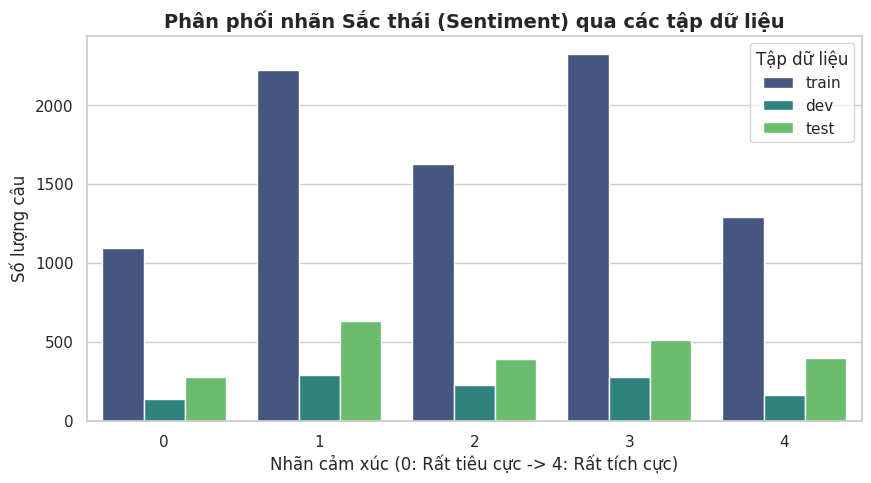

--- TỶ LỆ PHẦN TRĂM CÁC LỚP TRÊN TOÀN BỘ DATASET ---
Nhãn 0: 12.74%
Nhãn 1: 26.49%
Nhãn 2: 18.91%
Nhãn 3: 26.24%
Nhãn 4: 15.62%


In [88]:
# %%
# Trực quan hóa sự cân bằng giữa các lớp nhãn (từ 0 đến 4) qua 3 tập dữ liệu
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

sns.countplot(data=df_all, x='label', hue='split', palette='viridis')
plt.title('Phân phối nhãn Sắc thái (Sentiment) qua các tập dữ liệu', fontsize=14, fontweight='bold')
plt.xlabel('Nhãn cảm xúc (0: Rất tiêu cực -> 4: Rất tích cực)', fontsize=12)
plt.ylabel('Số lượng câu', fontsize=12)
plt.legend(title='Tập dữ liệu')
plt.show()

# Hiển thị bảng tỷ lệ phần trăm chi tiết
print("--- TỶ LỆ PHẦN TRĂM CÁC LỚP TRÊN TOÀN BỘ DATASET ---")
dist_table = df_all['label'].value_counts(normalize=True).sort_index() * 100
for label, pct in dist_table.items():
    print(f"Nhãn {label}: {pct:.2f}%")

### **Phân tích độ dài văn bản**

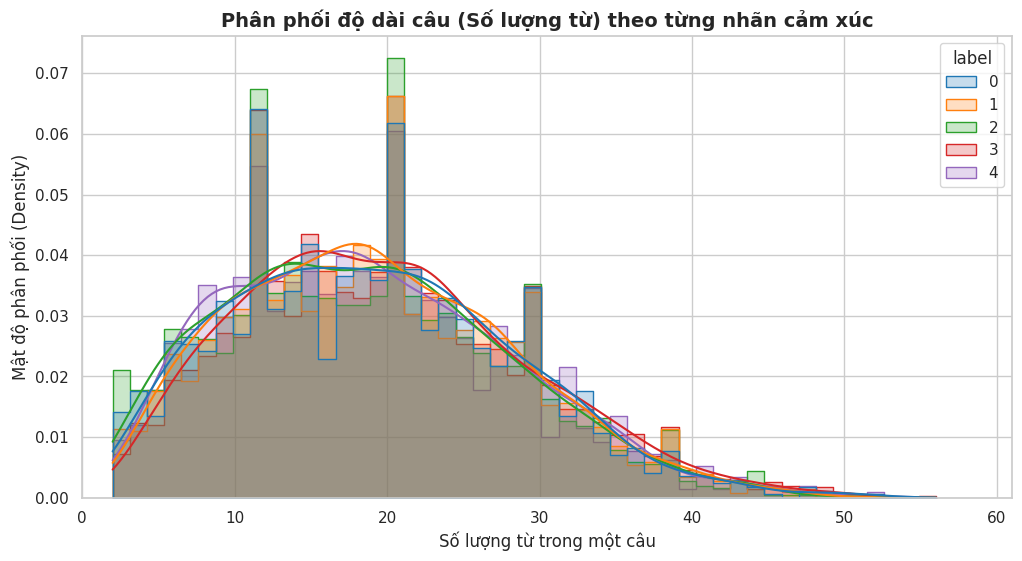

--- THỐNG KÊ MÔ TẢ VỀ ĐỘ DÀI VĂN BẢN (SỐ TỪ) ---
count    11855.000000
mean        19.168705
std          9.206627
min          2.000000
25%         12.000000
50%         18.000000
75%         25.000000
max         56.000000
Name: word_count, dtype: float64


In [89]:
# %%
# Tính số lượng từ (word count) trong mỗi câu văn
df_all['word_count'] = df_all['text'].apply(lambda x: len(x.split()))

# Trực quan hóa độ dài câu bằng Biểu đồ mật độ (KDE Plot)
plt.figure(figsize=(12, 6))
sns.histplot(data=df_all, x='word_count', hue='label', kde=True, element='step', stat='density', common_norm=False, palette='tab10')
plt.title('Phân phối độ dài câu (Số lượng từ) theo từng nhãn cảm xúc', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng từ trong một câu', fontsize=12)
plt.ylabel('Mật độ phân phối (Density)', fontsize=12)
plt.xlim(0, df_all['word_count'].max() + 5)
plt.show()

print("--- THỐNG KÊ MÔ TẢ VỀ ĐỘ DÀI VĂN BẢN (SỐ TỪ) ---")
print(df_all['word_count'].describe())

### **Phân tích Từ vựng xuất hiện nhiều nhất**

/tmp/ipykernel_473/3117466327.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_pos), y=list(words_pos), ax=axes[0], palette='Blues_r')
/tmp/ipykernel_473/3117466327.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_neg), y=list(words_neg), ax=axes[1], palette='Reds_r')


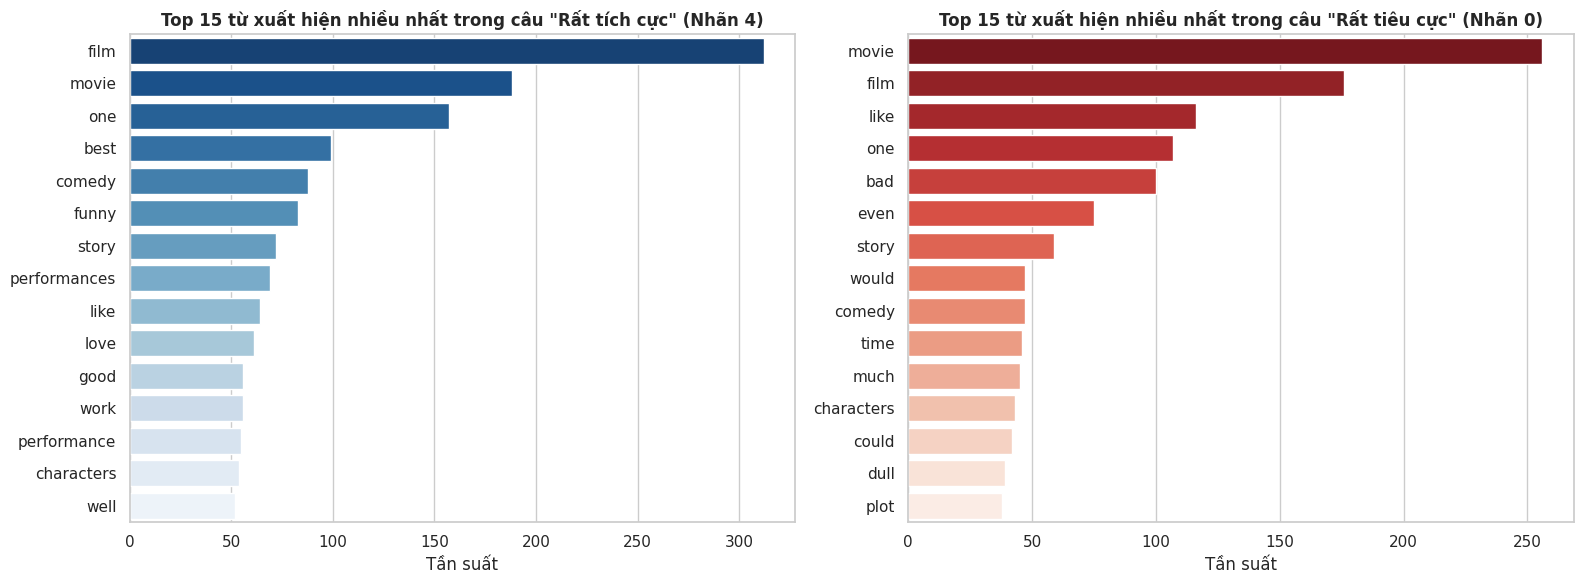

In [90]:
# %%
stop_words = set(stopwords.words('english'))

def get_top_words(corpus, n=15):
    words = []
    for text in corpus:
        # Chuyển chữ thường, bỏ stop words và chỉ giữ lại ký tự chữ cái (loại bỏ dấu câu rác)
        words.extend([w.lower() for w in text.split() if w.lower() not in stop_words and w.isalpha()])
    return Counter(words).most_common(n)

# Trích xuất top từ phổ biến từ tập Cực kỳ Tích cực (Nhãn 4) và Cực kỳ Tiêu cực (Nhãn 0)
top_positive = get_top_words(df_all[df_all['label'] == 4]['text'])
top_negative = get_top_words(df_all[df_all['label'] == 0]['text'])

# Vẽ biểu đồ so sánh từ vựng đặc trưng giữa 2 thái cực
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bên trái: Nhãn 4 (Rất tích cực)
words_pos, counts_pos = zip(*top_positive)
sns.barplot(x=list(counts_pos), y=list(words_pos), ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 15 từ xuất hiện nhiều nhất trong câu "Rất tích cực" (Nhãn 4)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tần suất')

# Bên phải: Nhãn 0 (Rất tiêu cực)
words_neg, counts_neg = zip(*top_negative)
sns.barplot(x=list(counts_neg), y=list(words_neg), ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 15 từ xuất hiện nhiều nhất trong câu "Rất tiêu cực" (Nhãn 0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tần suất')

plt.tight_layout()
plt.show()

### **TRANSFORMER GỐC**

In [91]:
# --- CELL 1: CÀI ĐẶT MÔ HÌNH TRANSFORMER GỐC ---
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # Đưa thông tin vị trí vào chuỗi embedding
        return x + self.pe[:, :x.size(1), :]

class OriginalTransformer(nn.Module):
    def __init__(self, vocab_size, num_classes, d_model=256, nhead=8, num_layers=3, dim_feedforward=1024, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        # Transformer Gốc sử dụng hàm GELU (hoặc ReLU)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu', # Lớp MLP gốc
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        x = self.embedding(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)

        # Mean pooling: Lấy trung bình tất cả các token để đại diện cho cả câu
        x = x.mean(dim=1)
        logits = self.classifier(x)
        return logits

print("Đã khởi tạo xong Class OriginalTransformer!")

Đã khởi tạo xong Class OriginalTransformer!


### **TRANSFORMER + SwiGLU MLP**

In [92]:
# --- CELL 2: CÀI ĐẶT TRANSFORMER + SwiGLU MLP ---

class SwiGLU(nn.Module):
    def __init__(self, in_features, hidden_features):
        super().__init__()
        # SwiGLU cần 2 phép chiếu tuyến tính (W1, W2) cho đầu vào và 1 (W3) cho đầu ra
        self.w1 = nn.Linear(in_features, hidden_features)
        self.w2 = nn.Linear(in_features, hidden_features)
        self.w3 = nn.Linear(hidden_features, in_features)

    def forward(self, x):
        # Công thức SwiGLU(x) = (Swish(xW1) ⊗ xW2)W3
        # Hàm Swish (hay SiLU) trong PyTorch là F.silu
        swish_out = F.silu(self.w1(x))
        return self.w3(swish_out * self.w2(x))

class SwiGLUTransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=1024, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)

        # BƯỚC QUAN TRỌNG: Thay thế lớp MLP (Linear + ReLU/GELU) bằng hàm SwiGLU
        self.mlp = SwiGLU(in_features=d_model, hidden_features=dim_feedforward)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask=None, src_key_padding_mask=None, is_causal=False):
        # 1. Attention block
        src2, _ = self.self_attn(src, src, src, attn_mask=src_mask, key_padding_mask=src_key_padding_mask, is_causal=is_causal)
        src = src + self.dropout(src2)
        src = self.norm1(src)

        # 2. SwiGLU MLP block thay cho FFN cũ
        src2 = self.mlp(src)
        src = src + self.dropout(src2)
        src = self.norm2(src)
        return src

class SwiGLUTransformer(nn.Module):
    def __init__(self, vocab_size, num_classes, d_model=256, nhead=8, num_layers=3, dim_feedforward=1024, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        # Sử dụng layer custom có SwiGLU
        self.layers = nn.ModuleList([
            SwiGLUTransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])

        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoder(x)

        for layer in self.layers:
            x = layer(x)

        x = x.mean(dim=1) # Mean pooling
        logits = self.classifier(x)
        return logits

print("Đã khởi tạo xong Class SwiGLUTransformer!")

Đã khởi tạo xong Class SwiGLUTransformer!


### **Khởi tạo mô hình**

In [93]:
# --- CELL 3: KHỞI TẠO MÔ HÌNH VÀ SIÊU THAM SỐ (HYPERPARAMETERS) ---
# Giả sử kích thước từ vựng (vocab_size) của bạn là số vocab đã tạo sau bước tokenizer
VOCAB_SIZE = len(vocab)
NUM_CLASSES = 5 # 5 sắc thái cảm xúc từ SST2
D_MODEL = 256
N_HEAD = 8
NUM_LAYERS = 3
DIM_FEEDFORWARD = 1024

# Kiểm tra thiết bị (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

# 1. Khởi tạo Transformer Gốc
model_original = OriginalTransformer(
    vocab_size=VOCAB_SIZE,
    num_classes=NUM_CLASSES,
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD
).to(device)

# 2. Khởi tạo Transformer + SwiGLU
model_swiglu = SwiGLUTransformer(
    vocab_size=VOCAB_SIZE,
    num_classes=NUM_CLASSES,
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD
).to(device)

print(f"Số lượng tham số mô hình gốc: {sum(p.numel() for p in model_original.parameters() if p.requires_grad):,}")
print(f"Số lượng tham số mô hình SwiGLU: {sum(p.numel() for p in model_swiglu.parameters() if p.requires_grad):,}")

Đang sử dụng thiết bị: cuda
Số lượng tham số mô hình gốc: 4,474,117
Số lượng tham số mô hình SwiGLU: 5,263,621


### Chạy huấn luyện (Train) cho cả 2 mô hình. Tinh chỉnh siêu tham số. Ghi nhận các chỉ số Accuracy, Loss, F1-Score.

In [94]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()

        total_loss += loss.item() * X.size(0)
        preds = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss   = criterion(logits, y)

            total_loss += loss.item() * X.size(0)
            preds = logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1, all_preds, all_labels

In [95]:
# --- TINH CHỈNH SIÊU THAM SỐ ---
configs = [
    {'lr': 3e-4, 'd_model': 256, 'num_layers': 3, 'dropout': 0.1},
    {'lr': 1e-4, 'd_model': 128, 'num_layers': 2, 'dropout': 0.3},
    {'lr': 1e-4, 'd_model': 256, 'num_layers': 3, 'dropout': 0.4},
]

tuning_results = []

for cfg in configs:
    model_tmp = OriginalTransformer(
        vocab_size=VOCAB_SIZE, num_classes=NUM_CLASSES,
        d_model=cfg['d_model'],
        nhead=4 if cfg['d_model'] == 128 else 8,
        num_layers=cfg['num_layers'],
        dim_feedforward=cfg['d_model'] * 4,
        dropout=cfg['dropout']
    ).to(device)

    hist = run_training(model_tmp, f"lr={cfg['lr']} d_model={cfg['d_model']} drop={cfg['dropout']}",
                        train_loader, dev_loader, num_epochs=5, lr=cfg['lr'])

    best_f1 = max(hist['dev_f1'])
    tuning_results.append({**cfg, 'best_dev_f1': best_f1})

# In bảng so sánh
print("\n" + "="*65)
print("  BẢNG SO SÁNH SIÊU THAM SỐ")
print("="*65)
print(f"{'lr':>8} | {'d_model':>7} | {'layers':>6} | {'dropout':>7} | {'Best Dev F1':>11}")
print("-"*55)
for r in tuning_results:
    mark = " ← TỐT NHẤT" if r['best_dev_f1'] == max(x['best_dev_f1'] for x in tuning_results) else ""
    print(f"{r['lr']:>8} | {r['d_model']:>7} | {r['num_layers']:>6} | {r['dropout']:>7} | {r['best_dev_f1']:>11.4f}{mark}")


  BẮT ĐẦU HUẤN LUYỆN: lr=0.0003 d_model=256 drop=0.1
 Epoch | Train Loss | Train Acc | Train F1 |  Dev Loss |  Dev Acc |  Dev F1
----------------------------------------------------------------------
     1 |     1.5805 |    0.2736 |   0.2124 |    1.5282 |   0.3188 |  0.2702
     2 |     1.4654 |    0.3493 |   0.2863 |    1.5339 |   0.3388 |  0.2316
     3 |     1.3144 |    0.4334 |   0.3907 |    1.4471 |   0.3451 |  0.3175
     4 |     1.1351 |    0.5235 |   0.4999 |    1.5091 |   0.3542 |  0.3297
     5 |     0.9855 |    0.6024 |   0.5877 |    1.5967 |   0.3497 |  0.3272

✅ Best Dev F1 (lr=0.0003 d_model=256 drop=0.1): 0.3297

  BẮT ĐẦU HUẤN LUYỆN: lr=0.0001 d_model=128 drop=0.3
 Epoch | Train Loss | Train Acc | Train F1 |  Dev Loss |  Dev Acc |  Dev F1
----------------------------------------------------------------------
     1 |     1.5783 |    0.2694 |   0.1486 |    1.5641 |   0.2716 |  0.1180
     2 |     1.5569 |    0.2825 |   0.1582 |    1.5450 |   0.3006 |  0.1587
     3 |  

In [96]:
def run_training(model, model_name, train_loader, dev_loader,
                 num_epochs=20, lr=3e-4, device=device):

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'dev_loss':   [], 'dev_acc':   [], 'dev_f1':   []
    }
    best_dev_f1   = 0.0
    best_model_wts = None

    print(f"\n{'='*60}")
    print(f"  BẮT ĐẦU HUẤN LUYỆN: {model_name}")
    print(f"{'='*60}")
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Train F1':>8} | {'Dev Loss':>9} | {'Dev Acc':>8} | {'Dev F1':>7}")
    print(f"{'-'*70}")

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader, optimizer, criterion, device)
        dv_loss, dv_acc, dv_f1, _, _ = evaluate(model, dev_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['train_f1'].append(tr_f1)
        history['dev_loss'].append(dv_loss)
        history['dev_acc'].append(dv_acc)
        history['dev_f1'].append(dv_f1)

        # Lưu best model theo Dev F1
        if dv_f1 > best_dev_f1:
            best_dev_f1  = dv_f1
            import copy
            best_model_wts = copy.deepcopy(model.state_dict())

        print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | {tr_f1:>8.4f} | {dv_loss:>9.4f} | {dv_acc:>8.4f} | {dv_f1:>7.4f}")

    # Load lại trọng số tốt nhất
    model.load_state_dict(best_model_wts)
    print(f"\n✅ Best Dev F1 ({model_name}): {best_dev_f1:.4f}")
    return history

In [97]:
NUM_EPOCHS = 20
LR         = 3e-4

history_original = run_training(model_original, "Original Transformer",
                                train_loader, dev_loader,
                                num_epochs=NUM_EPOCHS, lr=LR)

history_swiglu   = run_training(model_swiglu,   "SwiGLU Transformer",
                                train_loader, dev_loader,
                                num_epochs=NUM_EPOCHS, lr=LR, device=device)


  BẮT ĐẦU HUẤN LUYỆN: Original Transformer
 Epoch | Train Loss | Train Acc | Train F1 |  Dev Loss |  Dev Acc |  Dev F1
----------------------------------------------------------------------
     1 |     1.5866 |    0.2721 |   0.1822 |    1.5260 |   0.3106 |  0.2578
     2 |     1.4606 |    0.3522 |   0.2989 |    1.4476 |   0.3733 |  0.2763
     3 |     1.3186 |    0.4287 |   0.3909 |    1.4271 |   0.3615 |  0.3104
     4 |     1.1554 |    0.5144 |   0.4918 |    1.5088 |   0.3497 |  0.3127
     5 |     0.9640 |    0.6055 |   0.5940 |    1.6585 |   0.3306 |  0.3169
     6 |     0.7855 |    0.6864 |   0.6789 |    1.9844 |   0.3279 |  0.3038
     7 |     0.5862 |    0.7786 |   0.7745 |    2.1875 |   0.3388 |  0.3111
     8 |     0.3990 |    0.8572 |   0.8548 |    2.6133 |   0.3479 |  0.3345
     9 |     0.2828 |    0.8970 |   0.8960 |    2.9060 |   0.3388 |  0.3243
    10 |     0.1775 |    0.9384 |   0.9367 |    3.3931 |   0.3306 |  0.3083


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import classification_report

def final_test_report(model, model_name, test_loader, device):
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, test_f1, preds, labels = evaluate(model, test_loader, criterion, device)

    print(f"\n{'='*60}")
    print(f"  KẾT QUẢ CUỐI CÙNG TRÊN TẬP TEST: {model_name}")
    print(f"{'='*60}")
    print(f"  Test Loss : {test_loss:.4f}")
    print(f"  Test Acc  : {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"  Test F1   : {test_f1:.4f}  (macro)")
    print(f"\n--- Chi tiết từng nhãn ---")
    print(classification_report(labels, preds,
                                target_names=['Rất tiêu cực','Tiêu cực','Trung lập','Tích cực','Rất tích cực'],
                                zero_division=0))

final_test_report(model_original, "Original Transformer", test_loader, device)
final_test_report(model_swiglu,   "SwiGLU Transformer",   test_loader, device)